# Assignment 4 — Visualisations

Ce notebook produit les 3 visualisations requises :
1. **Données brutes** : distribution géographique et temporelle
2. **Feature engineering** : distributions RFM avant/après normalisation
3. **Performances** : clusters K-Means + comparaison des 3 modèles

## 0. Imports

In [1]:
import sys
sys.path.append('..')

import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from src.data import load_data, clean_data, compute_rfm, remove_outliers, normalize_rfm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

os.makedirs('../plots', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Chargement des données

In [2]:
DATA_PATH = '../data/online_retail_II.csv'

df_raw   = load_data(DATA_PATH)
df_clean = clean_data(df_raw)
rfm      = compute_rfm(df_clean)
rfm_clean = remove_outliers(rfm)
rfm_scaled, scaler = normalize_rfm(rfm_clean)

# Charger les labels K-Means
with open('../models/kmeans.pkl', 'rb') as f:
    kmeans = pickle.load(f)

X = rfm_scaled[['R_scaled', 'F_scaled', 'M_scaled']].values
labels = kmeans.labels_
K = kmeans.n_clusters

print('Données chargées ✓')

[load_data] 1,067,371 lignes chargées.
[clean_data] Dataset nettoyé : (805549, 9)
[compute_rfm] 5,878 clients uniques.
[remove_outliers] 5,796 clients après suppression outliers.
Données chargées ✓


---
## Visualisation 1 — Données brutes
### Distribution géographique et évolution temporelle des ventes

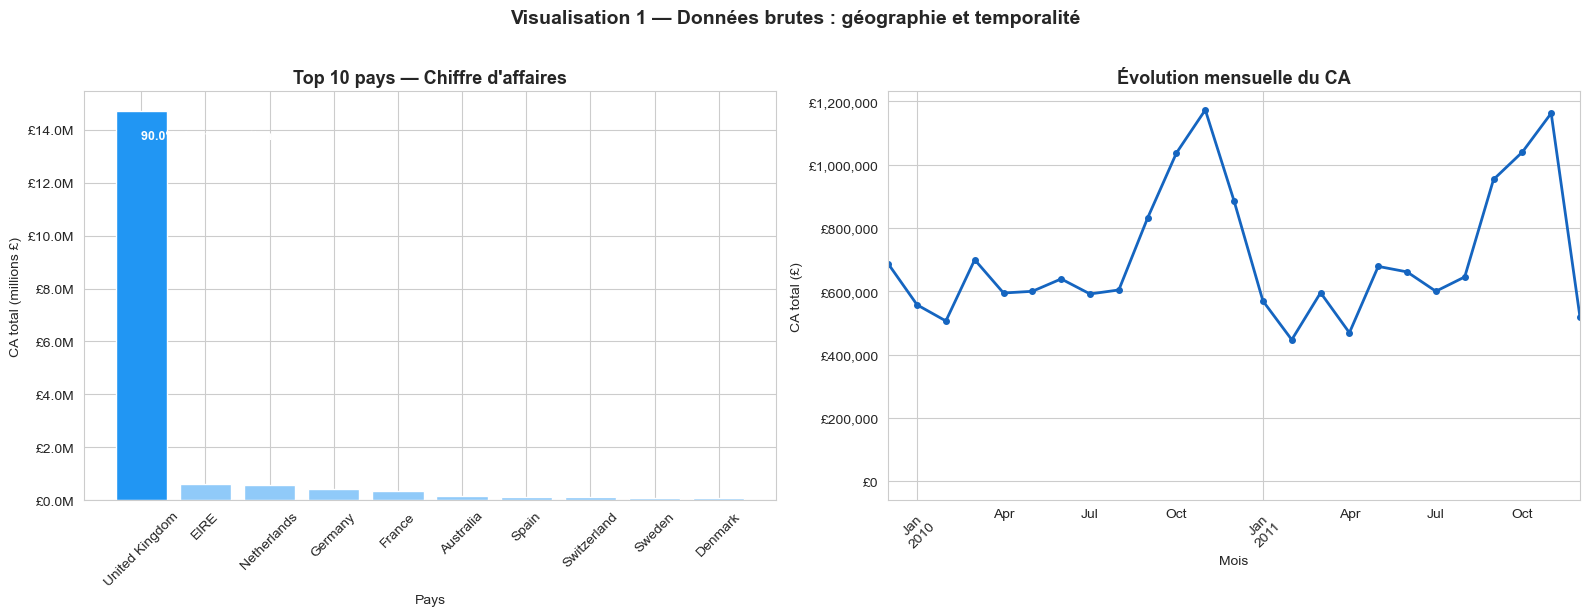

✓ plots/viz1_raw_data.png sauvegardé


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1a. Top 10 pays par CA
top_ca = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
bars = axes[0].bar(top_ca.index, top_ca.values / 1e6,
                   color=['#2196F3' if c == 'United Kingdom' else '#90CAF9' for c in top_ca.index],
                   edgecolor='white')
axes[0].set_title('Top 10 pays — Chiffre d\'affaires', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Pays')
axes[0].set_ylabel('CA total (millions £)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.1f}M'))

uk_pct = (df_clean['Country'].value_counts()['United Kingdom'] / len(df_clean) * 100).round(1)
axes[0].text(0, top_ca.values[0] / 1e6 * 0.95, f'{uk_pct}% des transactions',
             fontsize=9, color='white', fontweight='bold', ha='left', va='top')

# 1b. Évolution mensuelle du CA
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly = df_clean.groupby('YearMonth')['TotalPrice'].sum()
monthly.plot(ax=axes[1], color='#1565C0', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Évolution mensuelle du CA', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('CA total (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)
axes[1].fill_between(range(len(monthly)), monthly.values, alpha=0.1, color='#1565C0')

plt.suptitle('Visualisation 1 — Données brutes : géographie et temporalité',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/viz1_raw_data.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ plots/viz1_raw_data.png sauvegardé')

---
## Visualisation 2 — Feature Engineering
### Distributions RFM avant et après normalisation

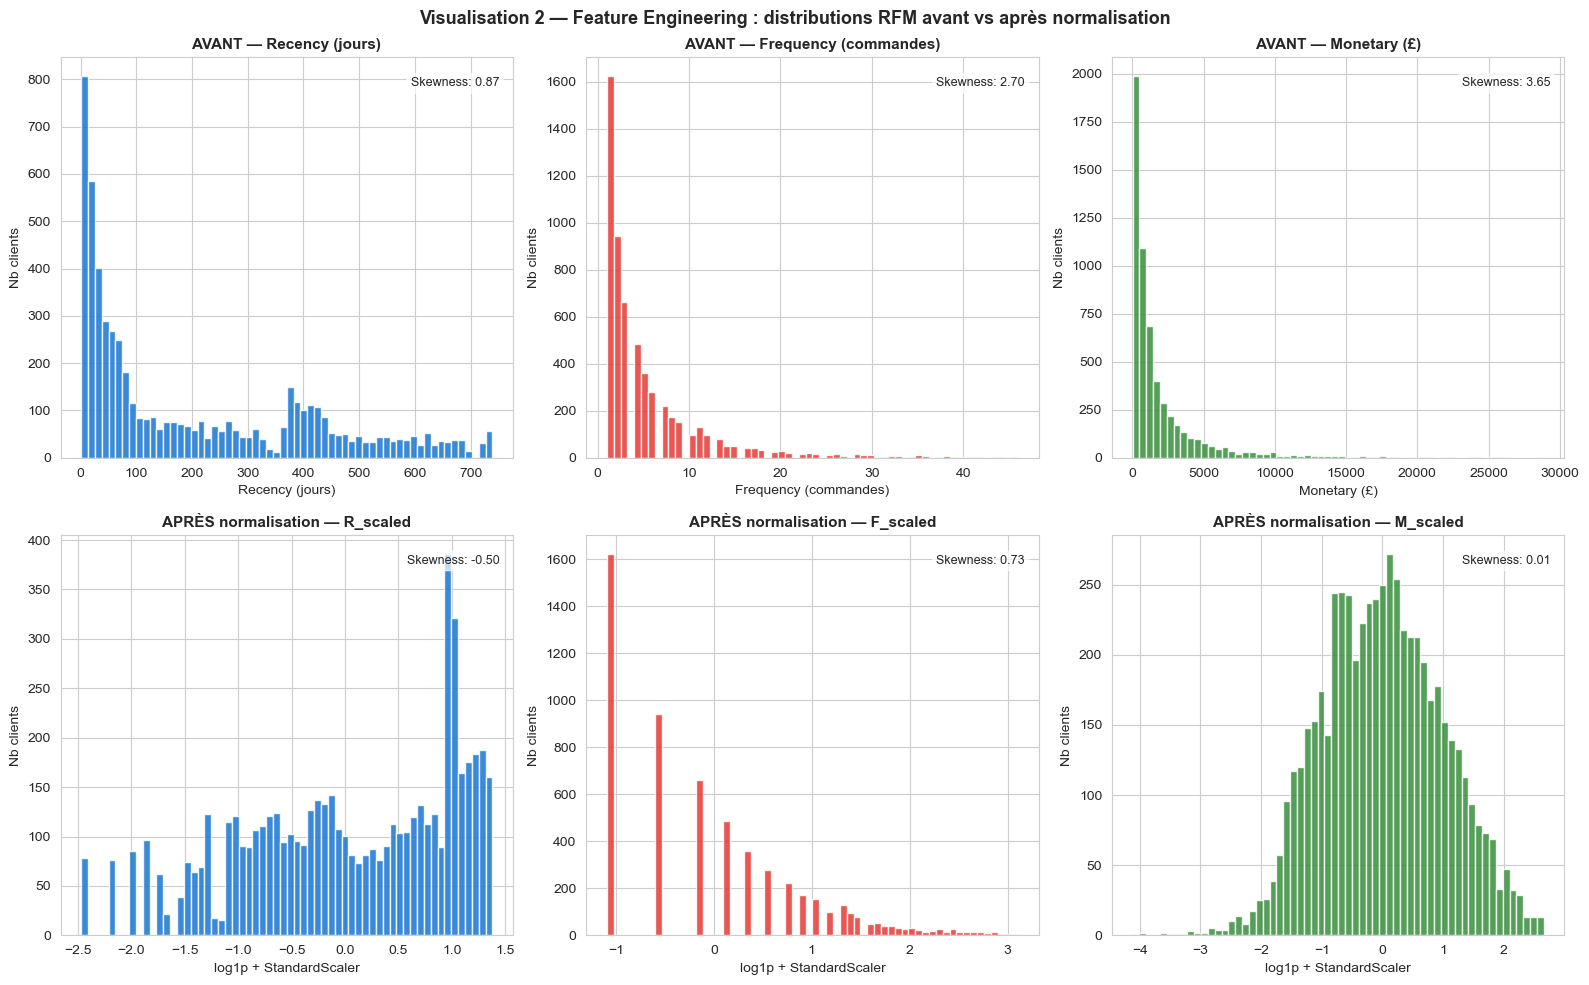

✓ plots/viz2_feature_engineering.png sauvegardé


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_raw    = ['Recency', 'Frequency', 'Monetary']
features_scaled = ['R_scaled', 'F_scaled', 'M_scaled']
colors = ['#1976D2', '#E53935', '#388E3C']
labels_viz = ['Recency (jours)', 'Frequency (commandes)', 'Monetary (£)']

for i, (raw, scaled, color, label) in enumerate(
        zip(features_raw, features_scaled, colors, labels_viz)):

    # Ligne 1 : avant
    axes[0, i].hist(rfm_clean[raw], bins=60, color=color, edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'AVANT — {label}', fontweight='bold', fontsize=11)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Nb clients')
    skew = rfm_clean[raw].skew()
    axes[0, i].text(0.97, 0.95, f'Skewness: {skew:.2f}',
                    transform=axes[0, i].transAxes, ha='right', va='top',
                    fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Ligne 2 : après
    axes[1, i].hist(rfm_scaled[scaled], bins=60, color=color, edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'APRÈS normalisation — {scaled}', fontweight='bold', fontsize=11)
    axes[1, i].set_xlabel(f'log1p + StandardScaler')
    axes[1, i].set_ylabel('Nb clients')
    skew2 = rfm_scaled[scaled].skew()
    axes[1, i].text(0.97, 0.95, f'Skewness: {skew2:.2f}',
                    transform=axes[1, i].transAxes, ha='right', va='top',
                    fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Visualisation 2 — Feature Engineering : distributions RFM avant vs après normalisation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/viz2_feature_engineering.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ plots/viz2_feature_engineering.png sauvegardé')

---
## Visualisation 3 — Performances des modèles
### Clusters K-Means + comparaison des 3 modèles + profils RFM

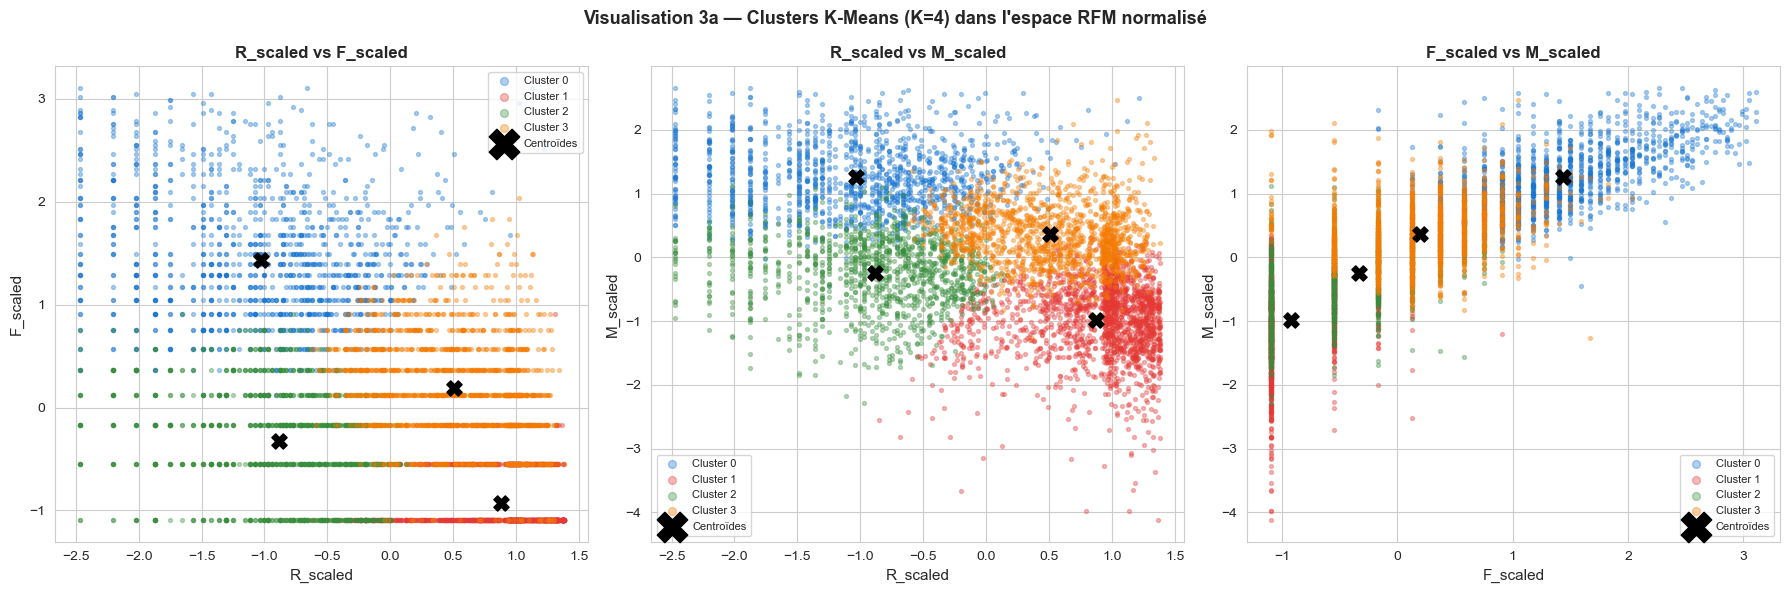

✓ plots/viz3a_kmeans_clusters.png sauvegardé


In [5]:
# 3a. Scatter plots des clusters K-Means
cluster_colors = ['#1976D2', '#E53935', '#388E3C', '#F57C00']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [('R_scaled', 'F_scaled'), ('R_scaled', 'M_scaled'), ('F_scaled', 'M_scaled')]

for ax, (x, y) in zip(axes, pairs):
    for k in range(K):
        mask = labels == k
        ax.scatter(rfm_scaled.loc[mask, x], rfm_scaled.loc[mask, y],
                   c=cluster_colors[k], alpha=0.35, s=8, label=f'Cluster {k}')
    # Centroïdes
    feat_idx = {'R_scaled': 0, 'F_scaled': 1, 'M_scaled': 2}
    cx = kmeans.cluster_centers_[:, feat_idx[x]]
    cy = kmeans.cluster_centers_[:, feat_idx[y]]
    ax.scatter(cx, cy, c='black', s=120, marker='X', zorder=5, label='Centroïdes')
    ax.set_xlabel(x, fontsize=11)
    ax.set_ylabel(y, fontsize=11)
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend(markerscale=2, fontsize=8)

plt.suptitle('Visualisation 3a — Clusters K-Means (K=4) dans l\'espace RFM normalisé',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/viz3a_kmeans_clusters.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ plots/viz3a_kmeans_clusters.png sauvegardé')

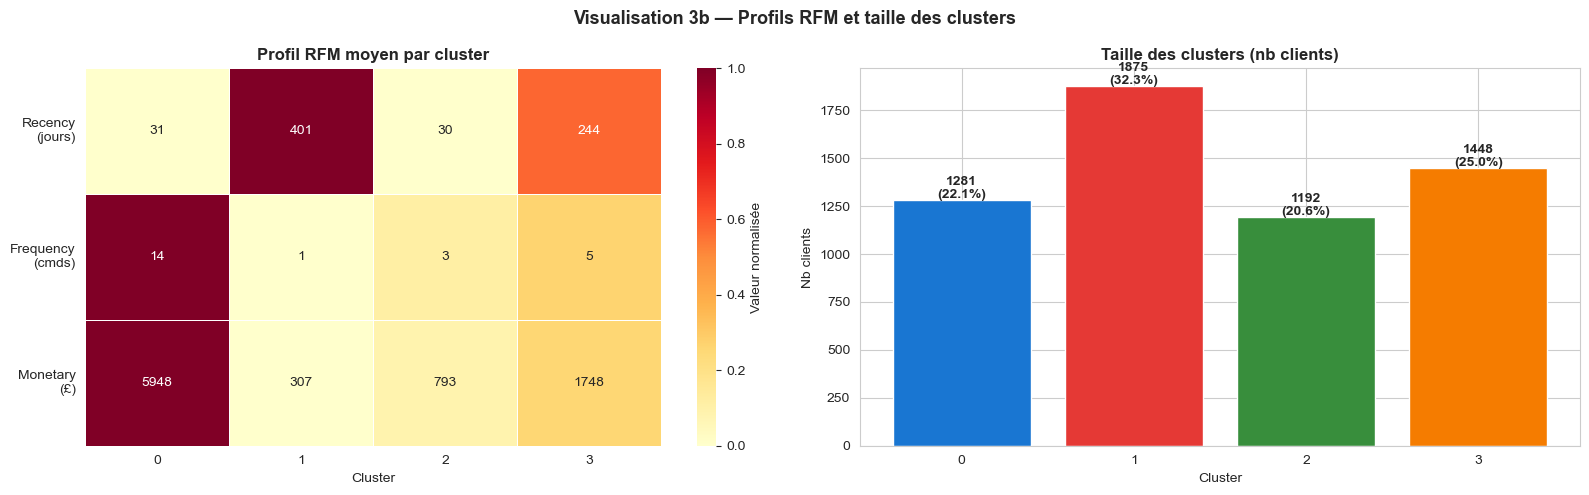

✓ plots/viz3b_cluster_profiles.png sauvegardé


In [6]:
# 3b. Profils RFM moyens par cluster (heatmap)
rfm_labeled = rfm_clean.copy()
rfm_labeled['Cluster'] = labels

profile = rfm_labeled.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

# Normaliser pour la heatmap (0-1)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(profile_norm.T, annot=profile.T, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Valeur normalisée'})
axes[0].set_title('Profil RFM moyen par cluster', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Cluster')
axes[0].set_yticklabels(['Recency\n(jours)', 'Frequency\n(cmds)', 'Monetary\n(£)'], rotation=0)

# Taille des clusters
sizes = rfm_labeled['Cluster'].value_counts().sort_index()
axes[1].bar(sizes.index.astype(str), sizes.values,
            color=cluster_colors[:K], edgecolor='white')
axes[1].set_title('Taille des clusters (nb clients)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Nb clients')
for i, v in enumerate(sizes.values):
    axes[1].text(i, v + 10, f'{v}\n({v/len(rfm_labeled)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Visualisation 3b — Profils RFM et taille des clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/viz3b_cluster_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ plots/viz3b_cluster_profiles.png sauvegardé')

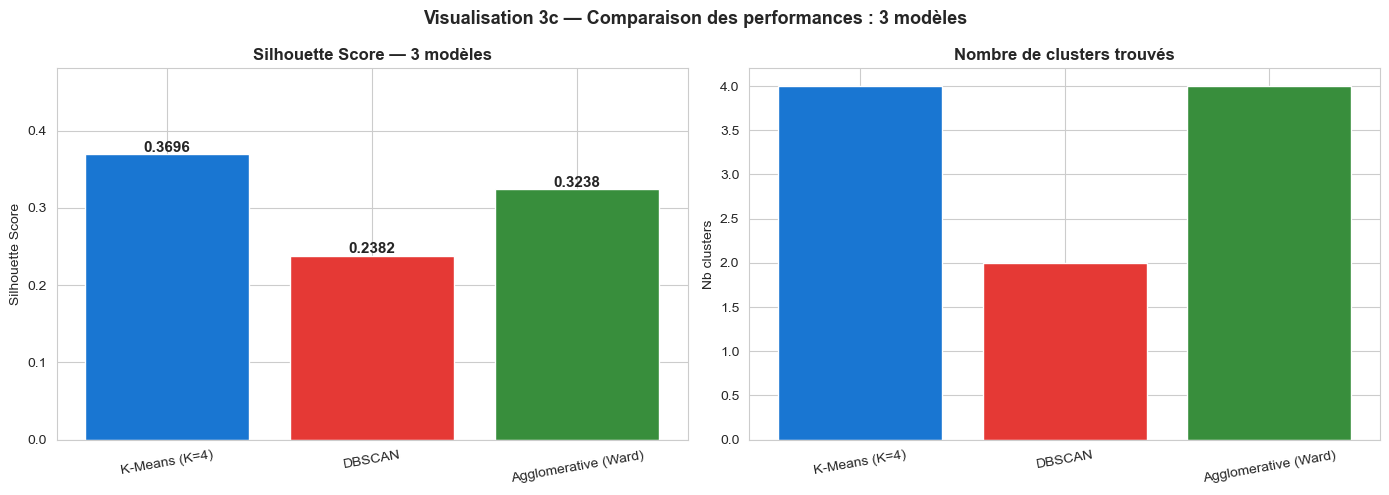

✓ plots/viz3c_model_comparison.png sauvegardé


In [7]:
# 3c. Comparaison des 3 modèles
metrics_df = pd.read_csv('../results/model_metrics.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['#1976D2', '#E53935', '#388E3C']

# Silhouette Score
bars = axes[0].bar(metrics_df['Modèle'], metrics_df['Silhouette'],
                   color=bar_colors, edgecolor='white')
axes[0].set_title('Silhouette Score — 3 modèles', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, metrics_df['Silhouette'].max() * 1.3)
for bar, val in zip(bars, metrics_df['Silhouette']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=10)

# Nb clusters
axes[1].bar(metrics_df['Modèle'], metrics_df['Nb clusters'],
            color=bar_colors, edgecolor='white')
axes[1].set_title('Nombre de clusters trouvés', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nb clusters')
axes[1].tick_params(axis='x', rotation=10)

plt.suptitle('Visualisation 3c — Comparaison des performances : 3 modèles',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/viz3c_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ plots/viz3c_model_comparison.png sauvegardé')

## Synthèse

| Visualisation | Fichier | Description |
|--------------|---------|-------------|
| 1 — Données brutes | `plots/viz1_raw_data.png` | Géographie + temporalité |
| 2 — Feature engineering | `plots/viz2_feature_engineering.png` | RFM avant/après normalisation |
| 3a — Clusters | `plots/viz3a_kmeans_clusters.png` | Scatter plots K-Means |
| 3b — Profils | `plots/viz3b_cluster_profiles.png` | Heatmap RFM + tailles |
| 3c — Comparaison | `plots/viz3c_model_comparison.png` | Métriques 3 modèles |

Toutes les visualisations sont sauvegardées dans `plots/`.